# 10 Financials EDA

This notebook is designed to understand the **financial view itself**, with three concrete purposes:

1. **Snorkel functions**  
   Identify variables that can support interpretable and stable labeling rules.

2. **Imputation strategy**  
   Understand missingness patterns and decide whether a feature should be:
   - imputed
   - kept with a missing flag
   - summarized
   - dropped

3. **Later modeling / feature engineering**  
   Understand which financial variables are:
   - useful as raw features
   - better transformed into engineered flags or summaries
   - too sparse or redundant to keep as-is



## Imports and project path setup

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [3]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from master_thesis.data_utils import load_raw, save_processed

## Load financial dataset

This notebook focuses only on the **financial view**.  
If your file name changes, update it here.

In [4]:
df_financials = load_raw("financials_clean.csv", low_memory=False)

print("Shape:", df_financials.shape)
display(df_financials.head())

Shape: (3529, 54)


,moodys_bvd_id,moodys_company_name,Join_Year,closing_year,closing_date,created_at_utc,Status,Implied_rating,risk_level,Financial_level,...,Long_term_liabilities_Equity_ratio,Short_term_liabilities_Equity_ratio,Interest_coverage_ratio,Solvency_ratio_Asset_based,Debt_Asset_ratio,ROE_using_Net_income,ROA_using_Net_income,Net_assets_turnover,Number_of_employees,financial_risk_score
0,GB02490104,Bio-Techne LTD,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,1.348341,29.784142,42.079646,76.259,0.195834,29.641,22.604,0.919,150.0,NaN
1,DE2110000553,Sartorius AG,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,A,Go ahead,Low financial risk,...,94.603031,67.825040,16.307692,38.106,0.359717,23.651,9.013,0.811,15942.0,1.0
2,LULB25789,SanisSure S.A.,2021,2021.0,2021-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,237.538807,34.619388,NaN,26.870,0.000000,NaN,NaN,NaN,NaN,NaN
3,DE7130049291,Amcor Flexibles Singen GmbH,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Ba,Take caution,NaN,...,73.990382,309.642979,9.423212,20.677,0.000000,NaN,NaN,4.936,1242.0,NaN
4,LULB186284,Amazon Web Services EMEA SARL,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Go ahead,Low financial risk,...,0.831076,235.324008,0.812609,29.748,0.000000,22.206,6.606,8.358,NaN,1.0


## Basic structure check

In [5]:
print("Column count:", df_financials.shape[1])
print("Duplicate rows:", df_financials.duplicated().sum())

display(df_financials.dtypes.astype(str).to_frame("dtype").head(50))

Column count: 54
Duplicate rows: 0


,dtype
moodys_bvd_id,str
moodys_company_name,str
Join_Year,int64
closing_year,float64
closing_date,str
created_at_utc,str
Status,str
Implied_rating,str
risk_level,str
Financial_level,str


## Standardize basic columns

This section is only for EDA convenience and does **not** change the source file.

In [6]:
df_financials_eda = df_financials.copy()

if "moodys_bvd_id" in df_financials_eda.columns:
    df_financials_eda["moodys_bvd_id"] = df_financials_eda["moodys_bvd_id"].astype("string").str.strip()

if "Join_Year" in df_financials_eda.columns:
    df_financials_eda["Join_Year"] = pd.to_numeric(df_financials_eda["Join_Year"], errors="coerce").astype("Int64")

print("Shape:", df_financials_eda.shape)
display(df_financials_eda.head())

Shape: (3529, 54)


,moodys_bvd_id,moodys_company_name,Join_Year,closing_year,closing_date,created_at_utc,Status,Implied_rating,risk_level,Financial_level,...,Long_term_liabilities_Equity_ratio,Short_term_liabilities_Equity_ratio,Interest_coverage_ratio,Solvency_ratio_Asset_based,Debt_Asset_ratio,ROE_using_Net_income,ROA_using_Net_income,Net_assets_turnover,Number_of_employees,financial_risk_score
0,GB02490104,Bio-Techne LTD,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,1.348341,29.784142,42.079646,76.259,0.195834,29.641,22.604,0.919,150.0,NaN
1,DE2110000553,Sartorius AG,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,A,Go ahead,Low financial risk,...,94.603031,67.825040,16.307692,38.106,0.359717,23.651,9.013,0.811,15942.0,1.0
2,LULB25789,SanisSure S.A.,2021,2021.0,2021-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,237.538807,34.619388,NaN,26.870,0.000000,NaN,NaN,NaN,NaN,NaN
3,DE7130049291,Amcor Flexibles Singen GmbH,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Ba,Take caution,NaN,...,73.990382,309.642979,9.423212,20.677,0.000000,NaN,NaN,4.936,1242.0,NaN
4,LULB186284,Amazon Web Services EMEA SARL,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Go ahead,Low financial risk,...,0.831076,235.324008,0.812609,29.748,0.000000,22.206,6.606,8.358,NaN,1.0


## Screening table

This is the main quick-overview table for the view.
It helps assess:
- missingness
- uniqueness
- variable type
- broad usability

In [7]:
df_screening_financial = pd.DataFrame({
    "feature": df_financials_eda.columns,
    "dtype": df_financials_eda.dtypes.astype(str).values,
    "missing_pct": df_financials_eda.isna().mean().values * 100,
    "n_unique": df_financials_eda.nunique(dropna=True).values,
})

df_screening_financial["high_missing"] = (df_screening_financial["missing_pct"] >= 80).astype(int)
df_screening_financial["very_low_variation"] = (df_screening_financial["n_unique"] <= 2).astype(int)

display(df_screening_financial.sort_values("missing_pct", ascending=False).head(40))

,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation
33,Working_capital_th_DKK,float64,58.713517,1438,0,0
20,Costs_of_goods_soldth_DKK,float64,54.661377,1525,0,0
35,Gross_margin,float64,54.378011,1503,0,0
53,financial_risk_score,float64,53.669595,3,0,0
9,Financial_level,str,53.669595,3,0,0
13,Net_Salesth_DKK,float64,50.779258,1718,0,0
36,EBITDA_margin,float64,49.135733,1755,0,0
37,EBIT_margin,float64,43.355058,1921,0,0
34,Profit_margin,float64,43.100028,1932,0,0
51,Net_assets_turnover,float64,42.873335,1743,0,0


## Separate numeric and categorical financial features

In [8]:
id_like_cols = ["moodys_bvd_id", "Join_Year"]
id_like_cols = [c for c in id_like_cols if c in df_financials_eda.columns]

df_numeric_financial = df_financials_eda.select_dtypes(include=["number"]).copy()
numeric_cols = [c for c in df_numeric_financial.columns if c not in id_like_cols]

categorical_cols = [
    c for c in df_financials_eda.columns
    if c not in numeric_cols + id_like_cols
]

print("Numeric financial columns:", len(numeric_cols))
print("Categorical financial columns:", len(categorical_cols))

print("\nSample numeric columns:")
print(numeric_cols[:20])

print("\nSample categorical columns:")
print(categorical_cols[:20])

Numeric financial columns: 43
Categorical financial columns: 9

Sample numeric columns:
['closing_year', 'Number_of_months', 'Net_Salesth_DKK', 'Operating_revenue_Turnover_th_DKK', 'Gross_profit_th_DKK', 'EBIT_th_DKK', 'Net_income_th_DKK', 'Interest_paid_th_DKK', 'EBITDA_th_DKK', 'Costs_of_goods_soldth_DKK', 'Total_assets_th_DKK', 'Non-current_assetsth_DKK', 'Current_assets_th_DKK', 'Cash_and_cash_equivalent_th_DKK', "Total_shareholders'_funds_and_liabilitiesth_DKK", 'Long_term_debtth_DKK', 'Other_current_assetsth_DKK', 'Shareholders_funds_th_DKK', 'Current_liabilities_th_DKK', 'Non_current_liabilities_th_DKK']

Sample categorical columns:
['moodys_company_name', 'closing_date', 'created_at_utc', 'Status', 'Implied_rating', 'risk_level', 'Financial_level', 'output_text', 'Implied_rating - original']


# 1. EDA for Snorkel functions

The goal here is not prediction.  
The goal is to identify **human-readable and business-interpretable rule candidates**.

## Candidate variables for rule-based signals

This list should be edited over time as your understanding improves.

In [9]:
snorkel_numeric_candidates = [
    "financial_risk_score",
    "current_ratio",
    "gearing",
    "short_term_gearing",
    "long_term_gearing",
    "interest_coverage_ratio",
    "profit_margin",
    "ebit_margin",
    "solvency_ratio_asset_based",
    "debt_asset_ratio",
    "long_term_liabilities_equity_ratio",
    "short_term_liabilities_equity_ratio",
    "roe_net_income",
    "roa_net_income",
]

snorkel_categorical_candidates = [
    "Implied_rating",
    "Risk_level",
    "Financial_level",
]

snorkel_numeric_candidates = [c for c in snorkel_numeric_candidates if c in df_financials_eda.columns]
snorkel_categorical_candidates = [c for c in snorkel_categorical_candidates if c in df_financials_eda.columns]

print("Numeric Snorkel candidates:", snorkel_numeric_candidates)
print("Categorical Snorkel candidates:", snorkel_categorical_candidates)

Numeric Snorkel candidates: ['financial_risk_score']
Categorical Snorkel candidates: ['Implied_rating', 'Financial_level']


## Numeric rule candidate summary

This helps identify:
- possible thresholds
- extreme tails
- variables that might be meaningful as stress flags

In [10]:
if snorkel_numeric_candidates:
    df_snorkel_numeric_summary = (
        df_financials_eda[snorkel_numeric_candidates]
        .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        .T
    )
    display(df_snorkel_numeric_summary)
else:
    print("No numeric Snorkel candidates found.")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
financial_risk_score,1635.0,1.459939,0.685631,1.0,1.0,1.0,1.0,1.0,2.0,3.0,3.0,3.0


## Categorical rule candidate summary

This helps identify categories that are:
- frequent enough to support a rule
- clearly interpretable

In [11]:
df_snorkel_categorical_summary_list = []

for col in snorkel_categorical_candidates:
    df_temp = (
        df_financials_eda[col]
        .fillna("MISSING")
        .value_counts(dropna=False)
        .reset_index()
    )
    df_temp.columns = ["value", "count"]
    df_temp["feature"] = col
    df_temp["pct"] = df_temp["count"] / df_temp["count"].sum() * 100
    df_snorkel_categorical_summary_list.append(df_temp)

if df_snorkel_categorical_summary_list:
    df_snorkel_categorical_summary = pd.concat(df_snorkel_categorical_summary_list, ignore_index=True)
    display(df_snorkel_categorical_summary)
else:
    print("No categorical Snorkel candidates found.")

,value,count,feature,pct
0,Baa,1270,Implied_rating,35.987532
1,Ba,1260,Implied_rating,35.704165
2,B,389,Implied_rating,11.022953
3,A,351,Implied_rating,9.946160
4,Aa,158,Implied_rating,4.477189
5,Caa,48,Implied_rating,1.360159
6,Aaa,24,Implied_rating,0.680079
7,MISSING,15,Implied_rating,0.425050
8,C,11,Implied_rating,0.311703
9,Ca,3,Implied_rating,0.085010


## Histograms for numeric Snorkel candidates

These are useful for visual threshold inspection.

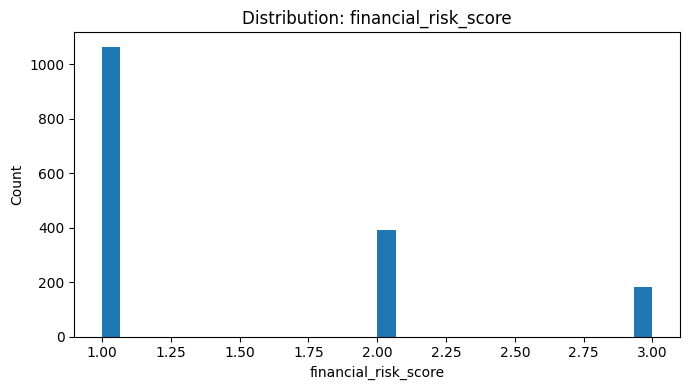

In [12]:
for col in snorkel_numeric_candidates:
    plt.figure(figsize=(7, 4))
    plt.hist(df_financials_eda[col].dropna(), bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Snorkel candidate decision table

This is where you document whether a feature looks suitable for:
- direct rule threshold
- categorical rule
- not suitable for Snorkel

In [13]:
df_snorkel_candidates_financial = df_screening_financial.copy()
df_snorkel_candidates_financial["snorkel_candidate"] = df_snorkel_candidates_financial["feature"].isin(
    snorkel_numeric_candidates + snorkel_categorical_candidates
)
df_snorkel_candidates_financial["snorkel_comment"] = ""

display(
    df_snorkel_candidates_financial[
        ["feature", "dtype", "missing_pct", "n_unique", "snorkel_candidate", "snorkel_comment"]
    ].sort_values(["snorkel_candidate", "missing_pct"], ascending=[False, True])
)

,feature,dtype,missing_pct,n_unique,snorkel_candidate,snorkel_comment
7,Implied_rating,str,0.425050,9,True,
9,Financial_level,str,53.669595,3,True,
53,financial_risk_score,float64,53.669595,3,True,
0,moodys_bvd_id,string,0.000000,1241,False,
1,moodys_company_name,str,0.000000,1236,False,
2,Join_Year,Int64,0.000000,28,False,
3,closing_year,float64,0.000000,28,False,
4,closing_date,str,0.000000,123,False,
5,created_at_utc,str,0.000000,2,False,
6,Status,str,0.000000,11,False,


# 2. EDA for imputation

The purpose here is to decide:
- should we impute?
- should we create a missing flag?
- should we summarize rather than impute raw fields?
- should some variables be dropped?

## Missingness overview

In [14]:
df_missing_financial = df_screening_financial.copy().sort_values("missing_pct", ascending=False)
display(df_missing_financial.head(50))

,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation
33,Working_capital_th_DKK,float64,58.713517,1438,0,0
20,Costs_of_goods_soldth_DKK,float64,54.661377,1525,0,0
35,Gross_margin,float64,54.378011,1503,0,0
53,financial_risk_score,float64,53.669595,3,0,0
9,Financial_level,str,53.669595,3,0,0
13,Net_Salesth_DKK,float64,50.779258,1718,0,0
36,EBITDA_margin,float64,49.135733,1755,0,0
37,EBIT_margin,float64,43.355058,1921,0,0
34,Profit_margin,float64,43.100028,1932,0,0
51,Net_assets_turnover,float64,42.873335,1743,0,0


## Missingness buckets

In [15]:
def missingness_bucket(x):
    if x == 0:
        return "0%"
    elif x < 5:
        return "<5%"
    elif x < 20:
        return "5-20%"
    elif x < 50:
        return "20-50%"
    elif x < 80:
        return "50-80%"
    else:
        return "80%+"

df_missing_financial["missing_bucket"] = df_missing_financial["missing_pct"].apply(missingness_bucket)

display(
    df_missing_financial["missing_bucket"]
    .value_counts()
    .sort_index()
    .to_frame("n_features")
)

,n_features
missing_bucket,
0%,9
20-50%,17
5-20%,19
50-80%,6
<5%,3


## Numeric correlation with missingness indicator

This helps identify whether a variable's missingness might itself be informative.

In [16]:
df_missing_indicator_summary_list = []

for col in numeric_cols:
    missing_flag = df_financials_eda[col].isna().astype(int)
    df_missing_indicator_summary_list.append({
        "feature": col,
        "missing_pct": missing_flag.mean() * 100,
        "n_missing": int(missing_flag.sum()),
        "n_non_missing": int((1 - missing_flag).sum()),
    })

df_missing_indicator_summary = pd.DataFrame(df_missing_indicator_summary_list)
display(df_missing_indicator_summary.sort_values("missing_pct", ascending=False).head(40))

,feature,missing_pct,n_missing,n_non_missing
22,Working_capital_th_DKK,58.713517,2072,1457
9,Costs_of_goods_soldth_DKK,54.661377,1929,1600
24,Gross_margin,54.378011,1919,1610
42,financial_risk_score,53.669595,1894,1635
2,Net_Salesth_DKK,50.779258,1792,1737
25,EBITDA_margin,49.135733,1734,1795
26,EBIT_margin,43.355058,1530,1999
23,Profit_margin,43.100028,1521,2008
40,Net_assets_turnover,42.873335,1513,2016
3,Operating_revenue_Turnover_th_DKK,39.076226,1379,2150


## Imputation decision table

Rule of thumb:
- low/moderate missing numeric: median + missing flag
- low/moderate missing categorical: explicit 'Missing' bucket
- very high missing: summarize or drop
- structurally meaningful missingness: keep missing flag

In [17]:
df_imputation_decisions_financial = df_screening_financial.copy()

def recommend_imputation(row):
    if row["dtype"] in ["float64", "int64", "Int64"]:
        if row["missing_pct"] == 0:
            return "keep_raw"
        elif row["missing_pct"] < 50:
            return "median_plus_missing_flag"
        elif row["missing_pct"] < 80:
            return "consider_summary_plus_flag"
        else:
            return "likely_drop_or_summary_only"
    else:
        if row["missing_pct"] == 0:
            return "keep_raw"
        elif row["missing_pct"] < 50:
            return "missing_category_bucket"
        elif row["missing_pct"] < 80:
            return "consider_grouping_or_missing_bucket"
        else:
            return "likely_drop_or_summary_only"

df_imputation_decisions_financial["imputation_recommendation"] = (
    df_imputation_decisions_financial.apply(recommend_imputation, axis=1)
)
df_imputation_decisions_financial["imputation_comment"] = ""

display(
    df_imputation_decisions_financial[
        ["feature", "dtype", "missing_pct", "n_unique", "imputation_recommendation", "imputation_comment"]
    ].sort_values("missing_pct", ascending=False)
)

,feature,dtype,missing_pct,n_unique,imputation_recommendation,imputation_comment
33,Working_capital_th_DKK,float64,58.713517,1438,consider_summary_plus_flag,
20,Costs_of_goods_soldth_DKK,float64,54.661377,1525,consider_summary_plus_flag,
35,Gross_margin,float64,54.378011,1503,consider_summary_plus_flag,
53,financial_risk_score,float64,53.669595,3,consider_summary_plus_flag,
9,Financial_level,str,53.669595,3,consider_grouping_or_missing_bucket,
13,Net_Salesth_DKK,float64,50.779258,1718,consider_summary_plus_flag,
36,EBITDA_margin,float64,49.135733,1755,median_plus_missing_flag,
37,EBIT_margin,float64,43.355058,1921,median_plus_missing_flag,
34,Profit_margin,float64,43.100028,1932,median_plus_missing_flag,
51,Net_assets_turnover,float64,42.873335,1743,median_plus_missing_flag,


# 3. EDA for feature engineering / later modeling

This section helps decide:
- which raw columns to keep
- which to transform into engineered signals
- which are redundant
- which should later be dropped or summarized

## Numeric correlation matrix

In [18]:
correlation_cols = [c for c in numeric_cols if df_financials_eda[c].notna().sum() > 20]

if correlation_cols:
    df_corr = df_financials_eda[correlation_cols].corr(numeric_only=True)
    display(df_corr)
else:
    print("No numeric columns with enough coverage for correlation analysis.")

,closing_year,Number_of_months,Net_Salesth_DKK,Operating_revenue_Turnover_th_DKK,Gross_profit_th_DKK,EBIT_th_DKK,Net_income_th_DKK,Interest_paid_th_DKK,EBITDA_th_DKK,Costs_of_goods_soldth_DKK,...,Long_term_liabilities_Equity_ratio,Short_term_liabilities_Equity_ratio,Interest_coverage_ratio,Solvency_ratio_Asset_based,Debt_Asset_ratio,ROE_using_Net_income,ROA_using_Net_income,Net_assets_turnover,Number_of_employees,financial_risk_score
closing_year,1.000000,-0.021210,0.033880,0.028066,0.033657,0.027157,0.028838,0.014357,0.030560,-0.004469,...,-0.000139,0.005228,-0.026303,0.024475,-0.029664,-0.008001,0.026805,0.020305,0.007247,-0.012835
Number_of_months,-0.021210,1.000000,0.002057,0.001692,0.003133,0.000488,0.000450,-0.002323,-0.001794,0.008231,...,0.015192,0.005452,-0.000298,0.025371,0.003719,-0.005443,0.024389,-0.027576,0.001379,0.000324
Net_Salesth_DKK,0.033880,0.002057,1.000000,0.999885,0.974638,0.941020,0.921227,0.405382,0.962518,0.941210,...,-0.005783,-0.008536,-0.008370,0.038271,0.014014,0.009243,0.039196,-0.045038,0.458559,-0.093378
Operating_revenue_Turnover_th_DKK,0.028066,0.001692,0.999885,1.000000,0.973636,0.938891,0.918775,0.409970,0.961073,0.941432,...,-0.004476,-0.008420,-0.002667,0.029541,0.003494,0.004729,0.031352,-0.030959,0.460971,-0.088187
Gross_profit_th_DKK,0.033657,0.003133,0.974638,0.973636,1.000000,0.948671,0.932761,0.433334,0.975203,0.840715,...,-0.003978,-0.006255,-0.000318,0.041321,-0.019900,0.000783,0.021000,-0.034168,0.389916,-0.091201
EBIT_th_DKK,0.027157,0.000488,0.941020,0.938891,0.948671,1.000000,0.994036,0.237937,0.990717,0.836816,...,-0.002587,-0.003904,-0.000798,0.038494,-0.012590,0.011114,0.036025,-0.025052,0.322697,-0.058109
Net_income_th_DKK,0.028838,0.000450,0.921227,0.918775,0.932761,0.994036,1.000000,0.195043,0.981516,0.813603,...,-0.002434,-0.003108,-0.002694,0.039291,-0.015904,0.013201,0.038782,-0.022419,0.293566,-0.053260
Interest_paid_th_DKK,0.014357,-0.002323,0.405382,0.409970,0.433334,0.237937,0.195043,1.000000,0.342037,0.337575,...,-0.001221,-0.008005,-0.002920,-0.018239,0.073098,-0.022611,-0.040972,-0.075609,0.286834,-0.086181
EBITDA_th_DKK,0.030560,-0.001794,0.962518,0.961073,0.975203,0.990717,0.981516,0.342037,1.000000,0.849667,...,-0.002757,-0.004822,-0.000792,0.040456,-0.007674,0.010561,0.033527,-0.040325,0.342898,-0.068365
Costs_of_goods_soldth_DKK,-0.004469,0.008231,0.941210,0.941432,0.840715,0.836816,0.813603,0.337575,0.849667,1.000000,...,-0.007082,-0.010691,-0.006290,0.023357,-0.004152,0.006800,0.035366,-0.020173,0.527176,-0.097302


## High-correlation pairs

Useful for later raw-feature pruning and engineering.

In [19]:
high_corr_threshold = 0.85
high_corr_pairs = []

if correlation_cols:
    df_corr_abs = df_financials_eda[correlation_cols].corr(numeric_only=True).abs()

    for i, col_1 in enumerate(df_corr_abs.columns):
        for col_2 in df_corr_abs.columns[i + 1:]:
            corr_value = df_corr_abs.loc[col_1, col_2]
            if corr_value >= high_corr_threshold:
                high_corr_pairs.append({
                    "feature_1": col_1,
                    "feature_2": col_2,
                    "abs_corr": corr_value,
                })

df_high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])
display(df_high_corr_pairs)

,feature_1,feature_2,abs_corr
74,Total_assets_th_DKK,Total_shareholders'_funds_and_liabilitiesth_DKK,1.000000
0,Net_Salesth_DKK,Operating_revenue_Turnover_th_DKK,0.999885
40,EBIT_th_DKK,Net_income_th_DKK,0.994036
82,Non-current_assetsth_DKK,Total_shareholders'_funds_and_liabilitiesth_DKK,0.993174
71,Total_assets_th_DKK,Non-current_assetsth_DKK,0.993174
...,...,...,...
76,Total_assets_th_DKK,Shareholders_funds_th_DKK,0.855102
68,Costs_of_goods_soldth_DKK,Cash_and_cash_equivalent_th_DKK,0.855071
101,Total_shareholders'_funds_and_liabilitiesth_DKK,Other_non_current_liabilitiesth_DKK,0.852454
78,Total_assets_th_DKK,Other_non_current_liabilitiesth_DKK,0.852453


## Low-variation / weak raw candidates

These are features that may be poor raw modeling inputs.

In [20]:
df_low_variation_financial = df_screening_financial[
    df_screening_financial["n_unique"] <= 2
].sort_values("missing_pct", ascending=False)

display(df_low_variation_financial)

,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation
5,created_at_utc,str,0.0,2,0,1


## Feature engineering decision table

This is the key output of the notebook.
Suggested categories:
- keep_raw
- engineer_flag
- engineer_summary
- keep_for_snorkel_only
- drop_raw

In [21]:
df_feature_decisions_financial = df_screening_financial.copy()

def recommend_feature_action(row):
    if row["missing_pct"] >= 80:
        return "drop_raw_or_summary_only"
    elif row["n_unique"] <= 2:
        return "possible_flag_only"
    elif row["dtype"] in ["float64", "int64", "Int64"]:
        return "candidate_raw_or_engineered_flag"
    else:
        return "candidate_category_or_grouping"

df_feature_decisions_financial["feature_engineering_decision"] = (
    df_feature_decisions_financial.apply(recommend_feature_action, axis=1)
)
df_feature_decisions_financial["feature_engineering_comment"] = ""

display(
    df_feature_decisions_financial[
        ["feature", "dtype", "missing_pct", "n_unique", "feature_engineering_decision", "feature_engineering_comment"]
    ].sort_values(["missing_pct", "n_unique"], ascending=[False, True])
)

,feature,dtype,missing_pct,n_unique,feature_engineering_decision,feature_engineering_comment
33,Working_capital_th_DKK,float64,58.713517,1438,candidate_raw_or_engineered_flag,
20,Costs_of_goods_soldth_DKK,float64,54.661377,1525,candidate_raw_or_engineered_flag,
35,Gross_margin,float64,54.378011,1503,candidate_raw_or_engineered_flag,
9,Financial_level,str,53.669595,3,candidate_category_or_grouping,
53,financial_risk_score,float64,53.669595,3,candidate_raw_or_engineered_flag,
13,Net_Salesth_DKK,float64,50.779258,1718,candidate_raw_or_engineered_flag,
36,EBITDA_margin,float64,49.135733,1755,candidate_raw_or_engineered_flag,
37,EBIT_margin,float64,43.355058,1921,candidate_raw_or_engineered_flag,
34,Profit_margin,float64,43.100028,1932,candidate_raw_or_engineered_flag,
51,Net_assets_turnover,float64,42.873335,1743,candidate_raw_or_engineered_flag,


# Final outputs

These are the decision-ready tables the rest of the pipeline should use.

In [22]:
display(df_screening_financial.head())
display(df_snorkel_candidates_financial.head())
display(df_imputation_decisions_financial.head())
display(df_feature_decisions_financial.head())

,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation
0,moodys_bvd_id,string,0.0,1241,0,0
1,moodys_company_name,str,0.0,1236,0,0
2,Join_Year,Int64,0.0,28,0,0
3,closing_year,float64,0.0,28,0,0
4,closing_date,str,0.0,123,0,0


,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation,snorkel_candidate,snorkel_comment
0,moodys_bvd_id,string,0.0,1241,0,0,False,
1,moodys_company_name,str,0.0,1236,0,0,False,
2,Join_Year,Int64,0.0,28,0,0,False,
3,closing_year,float64,0.0,28,0,0,False,
4,closing_date,str,0.0,123,0,0,False,


,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation,imputation_recommendation,imputation_comment
0,moodys_bvd_id,string,0.0,1241,0,0,keep_raw,
1,moodys_company_name,str,0.0,1236,0,0,keep_raw,
2,Join_Year,Int64,0.0,28,0,0,keep_raw,
3,closing_year,float64,0.0,28,0,0,keep_raw,
4,closing_date,str,0.0,123,0,0,keep_raw,


,feature,dtype,missing_pct,n_unique,high_missing,very_low_variation,feature_engineering_decision,feature_engineering_comment
0,moodys_bvd_id,string,0.0,1241,0,0,candidate_category_or_grouping,
1,moodys_company_name,str,0.0,1236,0,0,candidate_category_or_grouping,
2,Join_Year,Int64,0.0,28,0,0,candidate_raw_or_engineered_flag,
3,closing_year,float64,0.0,28,0,0,candidate_raw_or_engineered_flag,
4,closing_date,str,0.0,123,0,0,candidate_category_or_grouping,


## Save outputs

In [23]:
save_processed(df_screening_financial, "eda_financial_screening.csv")
save_processed(df_snorkel_candidates_financial, "eda_financial_snorkel_candidates.csv")
save_processed(df_imputation_decisions_financial, "eda_financial_imputation_decisions.csv")
save_processed(df_feature_decisions_financial, "eda_financial_feature_decisions.csv")

if 'df_high_corr_pairs' in globals() and not df_high_corr_pairs.empty:
    save_processed(df_high_corr_pairs, "eda_financial_high_corr_pairs.csv")

print("Saved EDA outputs to Data/processed/")

Saved EDA outputs to Data/processed/


## What to take forward

After finishing this notebook, the next decisions should be:

1. Which financial variables become Snorkel labeling functions?
2. Which variables get missing flags and imputation?
3. Which raw variables are kept vs replaced by engineered features?
4. Which variables are too sparse or redundant to keep for modeling?